In [1]:
import pandas as pd
import numpy as np
import warnings

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline

import optuna

import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [3]:
train.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
train['Irrigation_Need'] = train['Irrigation_Need'].map({'Low' : 0, 'Medium' : 1, 'High' : 2})

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Water_Sou

In [6]:
train.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Irrigation_Need
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177,0.446178
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939,0.560178
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000,0.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000,0.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000,0.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000,1.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000,2.000000


In [7]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()

In [8]:
for col in cat_cols:
    print(train[col].value_counts())

Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64
Mulching_Used
No     316453
Yes    313547
Name: count, dtype: int64
Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64


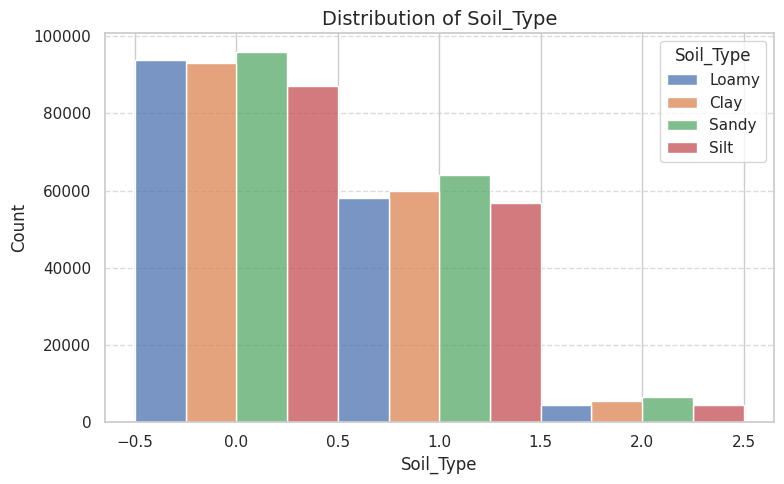

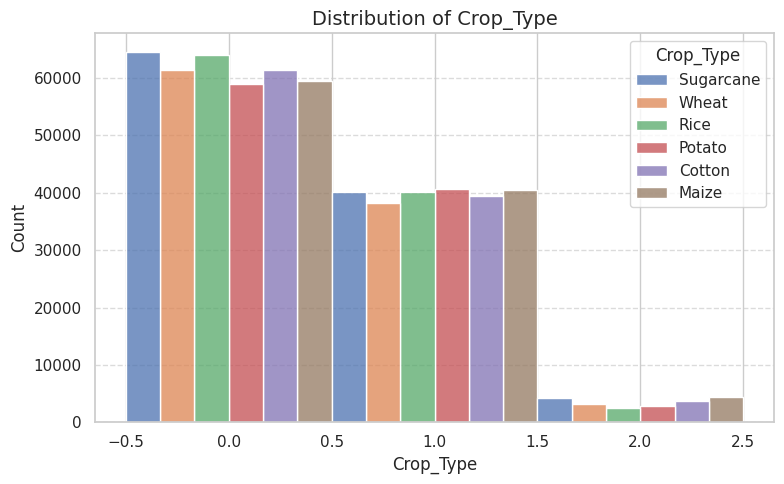

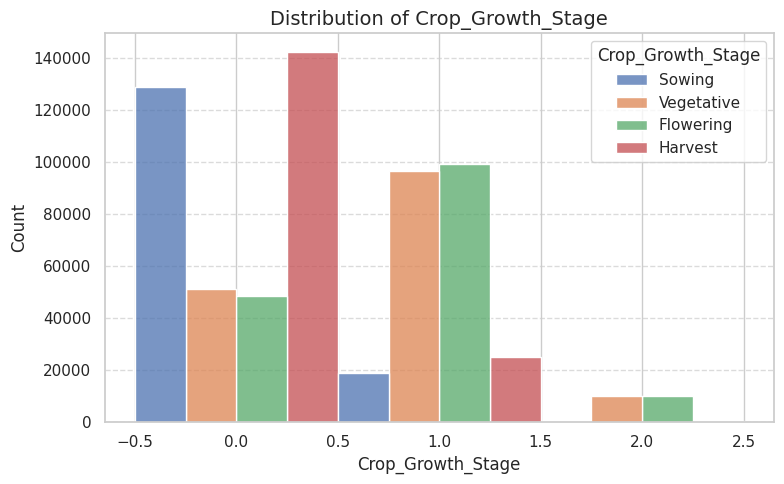

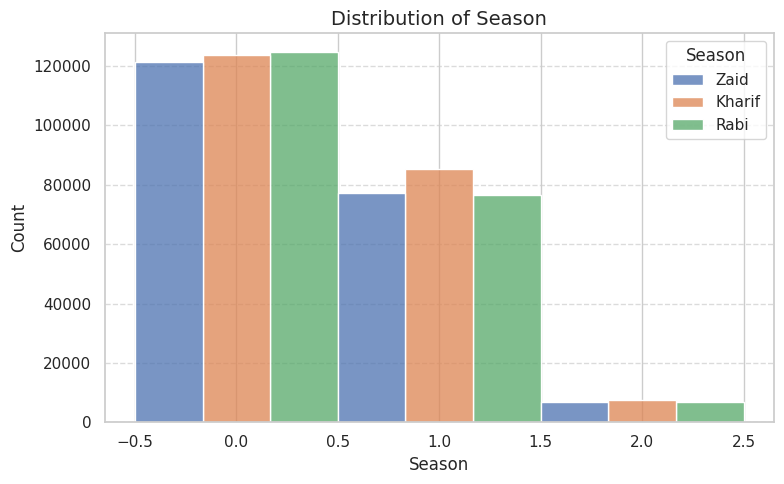

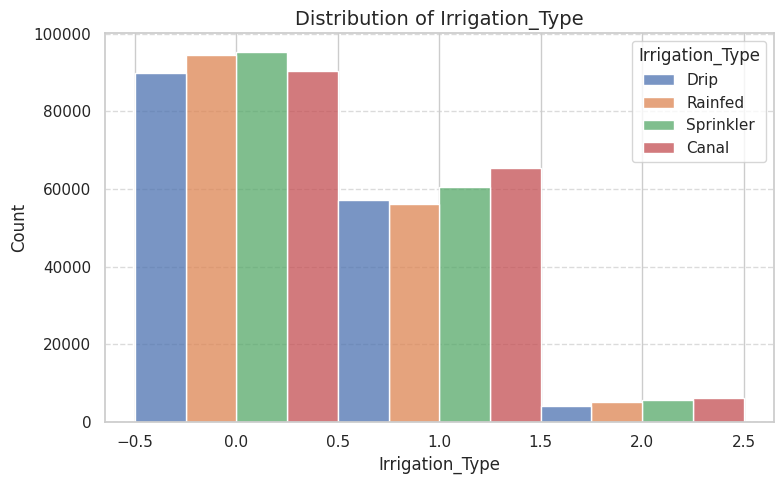

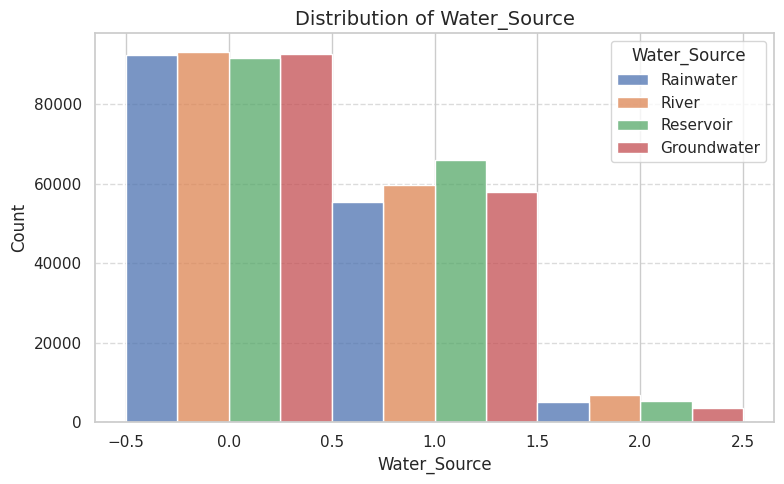

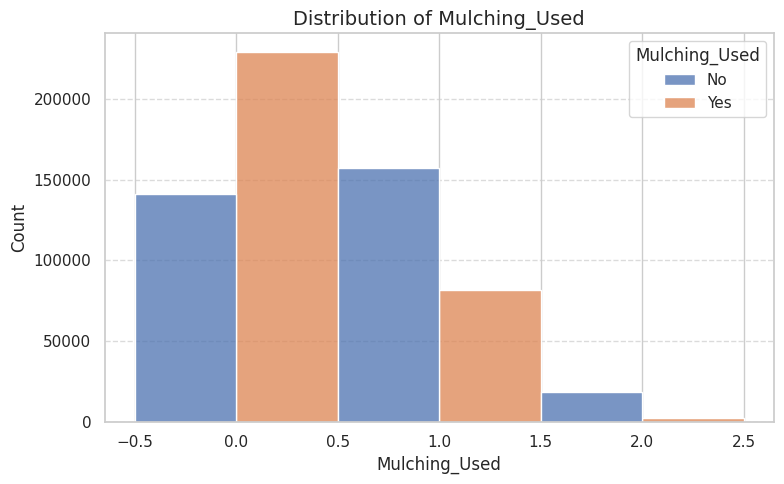

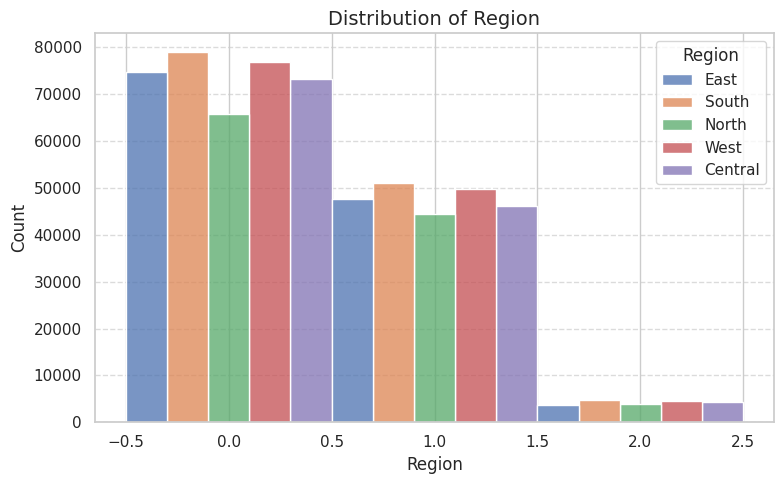

In [14]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x='Irrigation_Need',hue=col,multiple='dodge', discrete='True')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

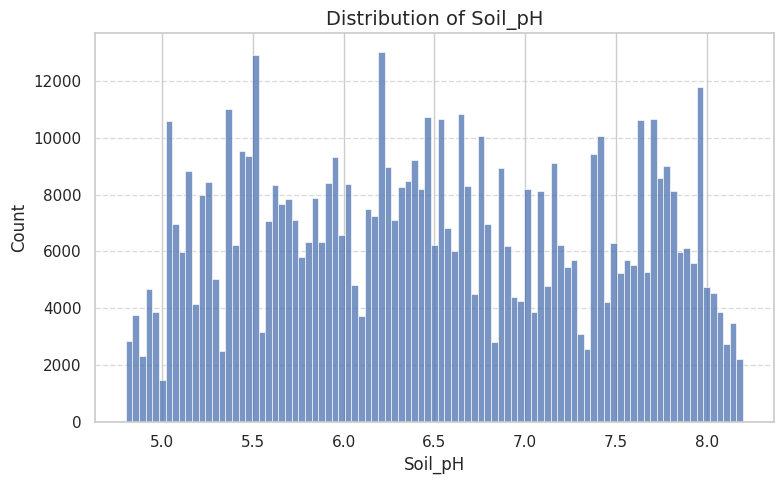

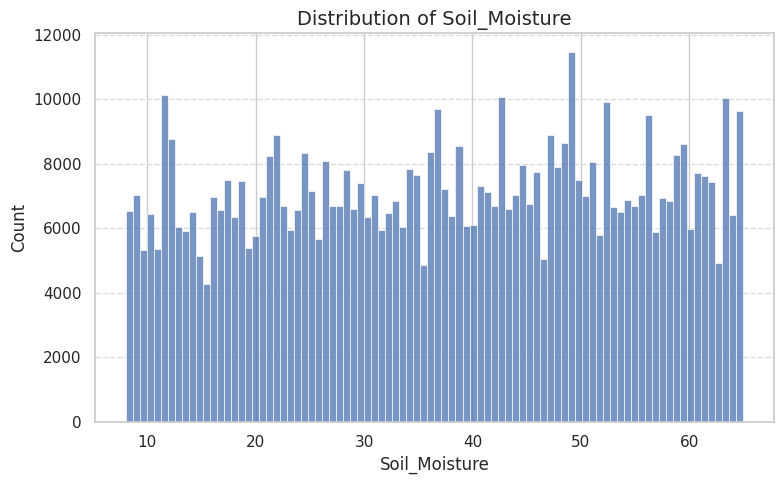

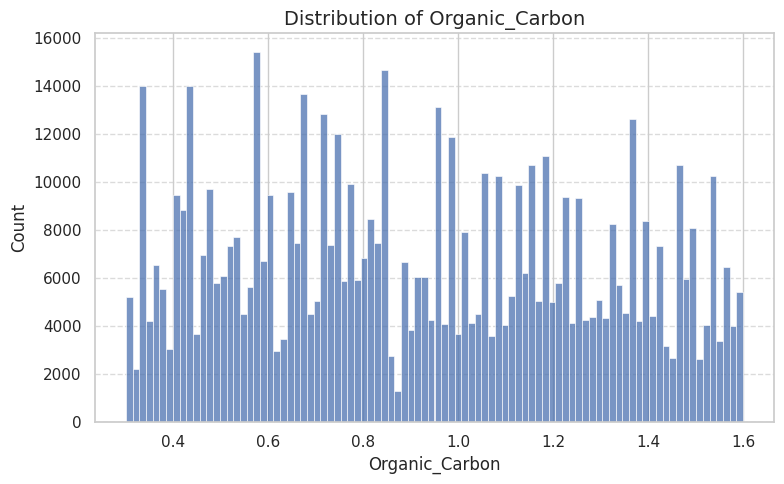

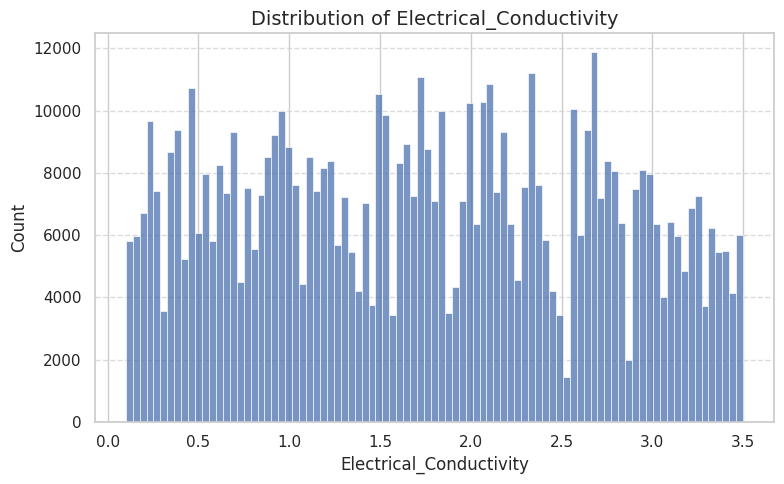

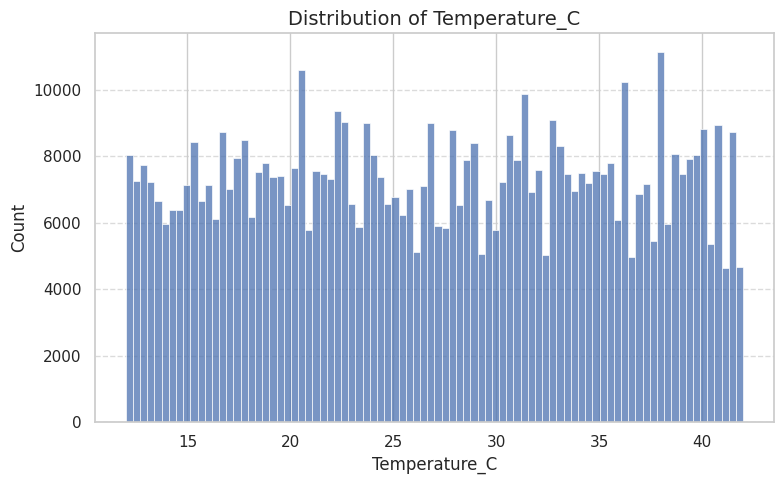

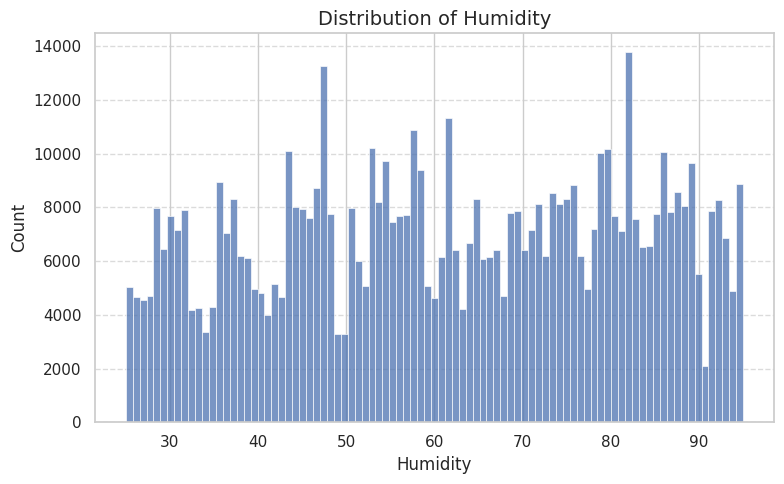

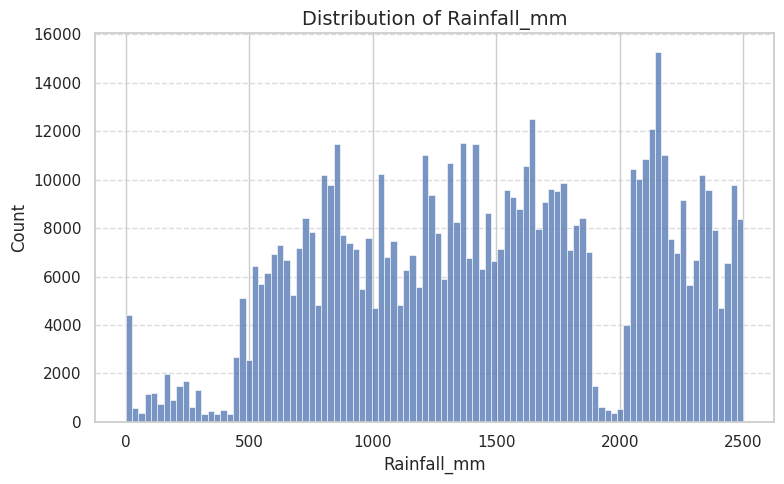

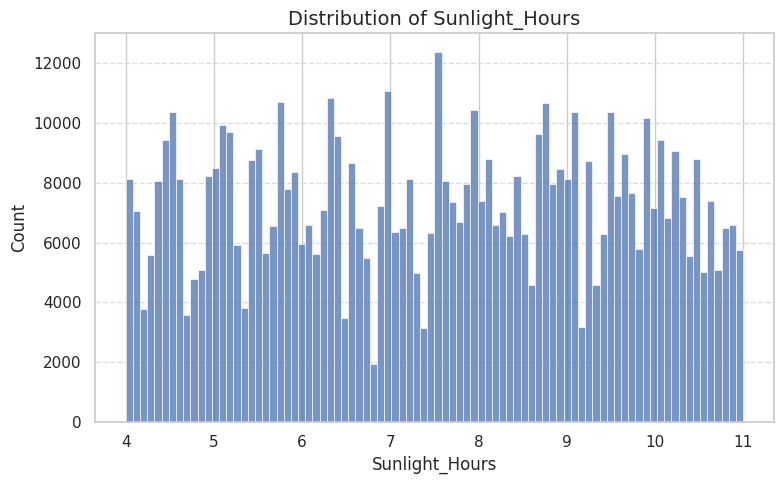

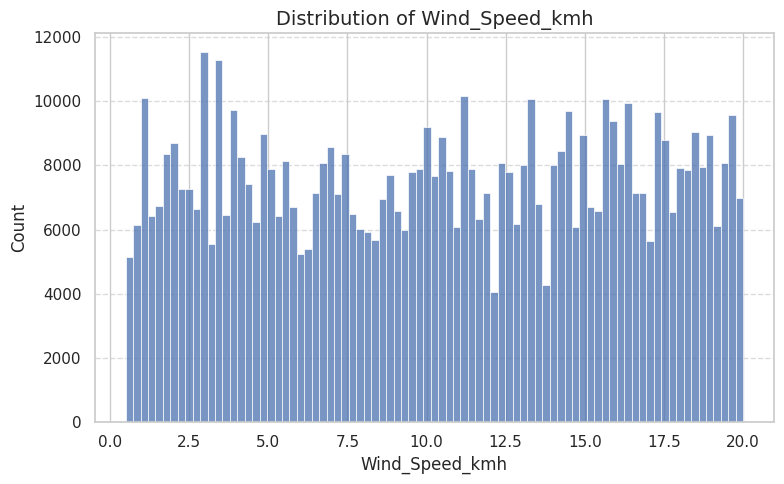

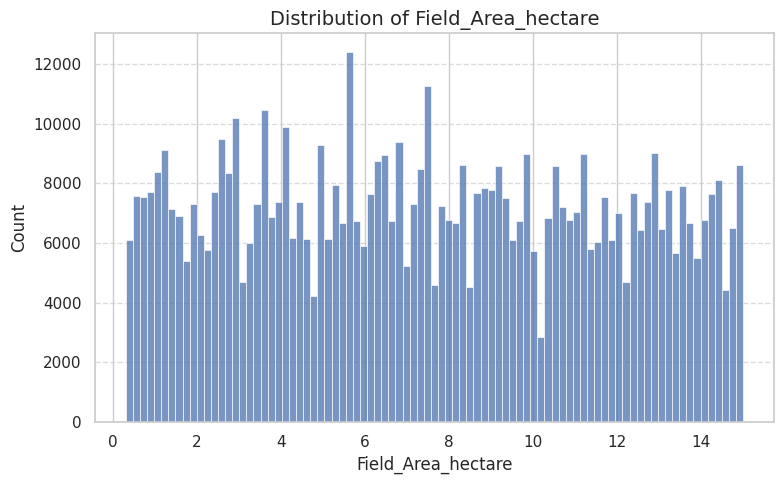

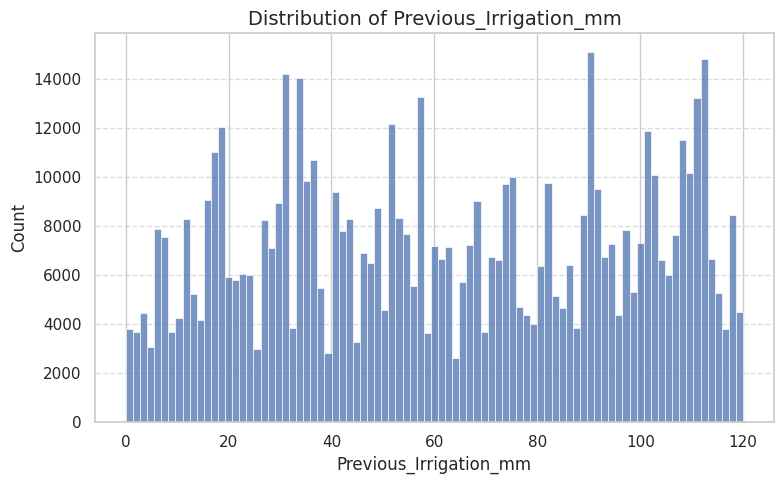

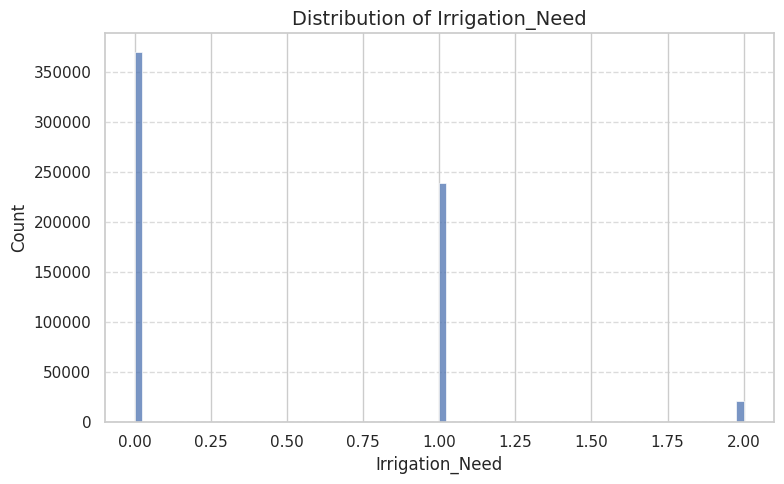

In [18]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x=col)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

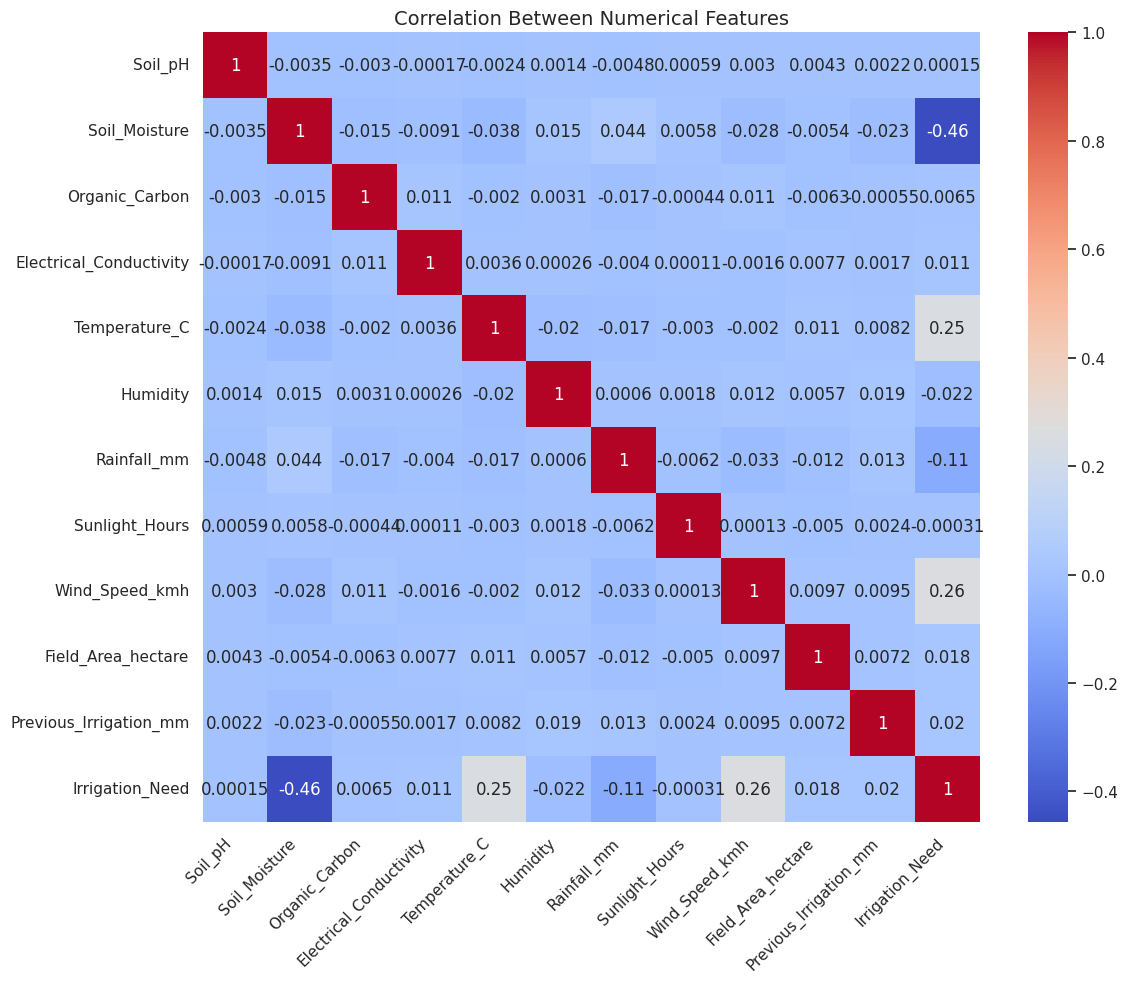

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
X = train.drop('Irrigation_Need', axis=1).copy()
y = train['Irrigation_Need']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=42)

In [21]:
def column_ratio(X):
    return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )
    
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='error')
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
)

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ('num',default_num_pipeline,make_column_selector(dtype_include=np.number))
    ],
    remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(objective = 'multiclass',random_state=42,verbose=-1))
])


In [22]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e0f5b8c3fb0>),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7e0f5b8c38f0>)])),
                ('classifier',
                 LGBMClassifier(objective='multiclass', random_state=42,
                                verbose=-1))])

In [24]:
test_pred = model.predict_proba(X_test)[:,1]
test_labels = (test_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, test_labels)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, test_labels))

Accuracy: 0.9530555555555555
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     73737
           1       0.98      0.97      0.98     48014
           2       0.00      0.00      0.00      4249

    accuracy                           0.95    126000
   macro avg       0.64      0.66      0.65    126000
weighted avg       0.92      0.95      0.94    126000



In [25]:
feature_importances = model['classifier'].feature_importances_
sorted( zip(feature_importances,model['preprocessor'].get_feature_names_out()),reverse=True)

[(np.int32(1472), 'num__Rainfall_mm'),
 (np.int32(1069), 'num__Temperature_C'),
 (np.int32(1026), 'num__Soil_Moisture'),
 (np.int32(871), 'num__Wind_Speed_kmh'),
 (np.int32(614), 'cat__Mulching_Used_No'),
 (np.int32(599), 'num__Humidity'),
 (np.int32(556), 'num__Previous_Irrigation_mm'),
 (np.int32(347), 'cat__Crop_Growth_Stage_Harvest'),
 (np.int32(341), 'cat__Crop_Growth_Stage_Sowing'),
 (np.int32(324), 'num__Field_Area_hectare'),
 (np.int32(307), 'num__Electrical_Conductivity'),
 (np.int32(268), 'num__Soil_pH'),
 (np.int32(253), 'num__Sunlight_Hours'),
 (np.int32(221), 'num__Organic_Carbon'),
 (np.int32(148), 'cat__Crop_Growth_Stage_Flowering'),
 (np.int32(146), 'cat__Crop_Growth_Stage_Vegetative'),
 (np.int32(44), 'cat__Mulching_Used_Yes'),
 (np.int32(40), 'cat__Water_Source_Reservoir'),
 (np.int32(29), 'cat__Water_Source_River'),
 (np.int32(24), 'cat__Crop_Type_Maize'),
 (np.int32(23), 'cat__Water_Source_Groundwater'),
 (np.int32(22), 'cat__Soil_Type_Clay'),
 (np.int32(22), 'cat__

In [28]:
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
submission['Irrigation_Need'] = model.predict_proba(test)[:,1]
submission[['id','Irrigation_Need']].to_csv("submission.csv", index=False)